In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from scipy import stats

In [92]:
# Step 2: Load the dataset
data = pd.read_csv(r'C:\Users\utkso\OneDrive\Desktop\bike+sharing+dataset\hour.csv')

# Drop non-predictive columns
data = data.drop(['dteday', 'instant'], axis=1)

In [93]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weathersit  17379 non-null  int64  
 8   temp        17379 non-null  float64
 9   atemp       17379 non-null  float64
 10  hum         17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  casual      17379 non-null  int64  
 13  registered  17379 non-null  int64  
 14  cnt         17379 non-null  int64  
dtypes: float64(4), int64(11)
memory usage: 2.0 MB
None


In [94]:
print(data.describe())

             season            yr          mnth            hr       holiday  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       2.501640      0.502561      6.537775     11.546752      0.028770   
std        1.106918      0.500008      3.438776      6.914405      0.167165   
min        1.000000      0.000000      1.000000      0.000000      0.000000   
25%        2.000000      0.000000      4.000000      6.000000      0.000000   
50%        3.000000      1.000000      7.000000     12.000000      0.000000   
75%        3.000000      1.000000     10.000000     18.000000      0.000000   
max        4.000000      1.000000     12.000000     23.000000      1.000000   

            weekday    workingday    weathersit          temp         atemp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       3.003683      0.682721      1.425283      0.496987      0.475775   
std        2.005771      0.465431      0.639357    

In [95]:
print(data.isnull().sum())

season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


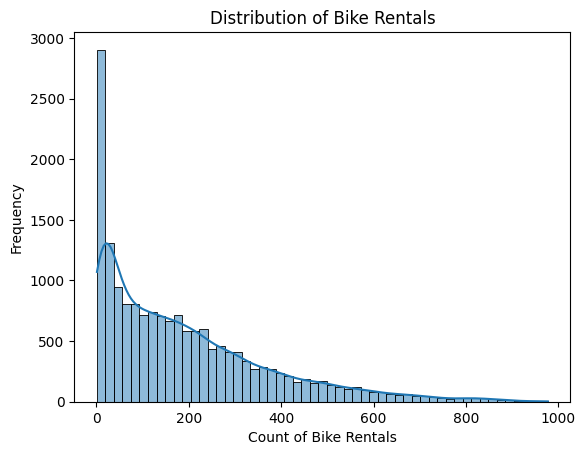

In [96]:
sns.histplot(data['cnt'], kde=True)
plt.title('Distribution of Bike Rentals')
plt.xlabel('Count of Bike Rentals')
plt.ylabel('Frequency')
plt.show()

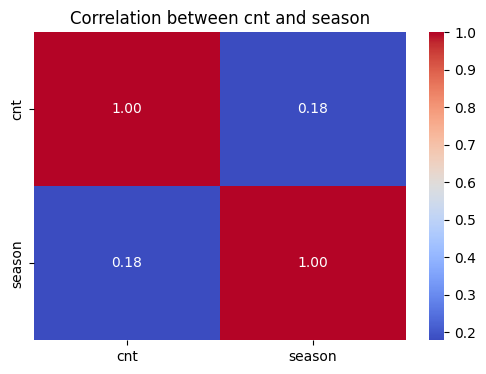

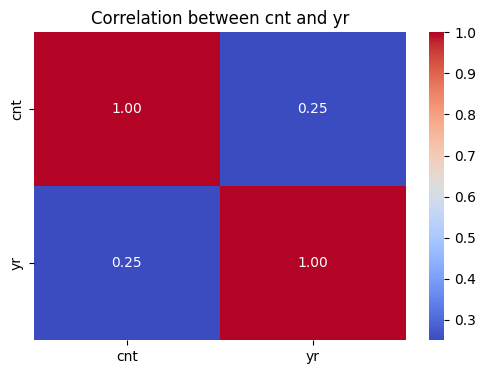

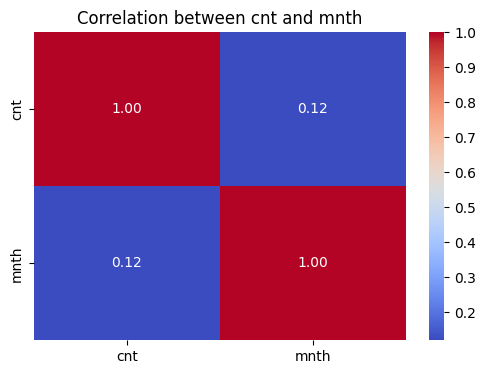

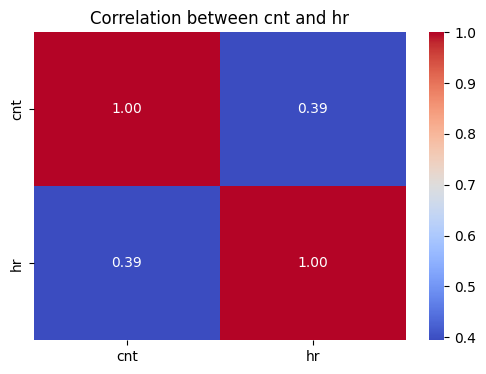

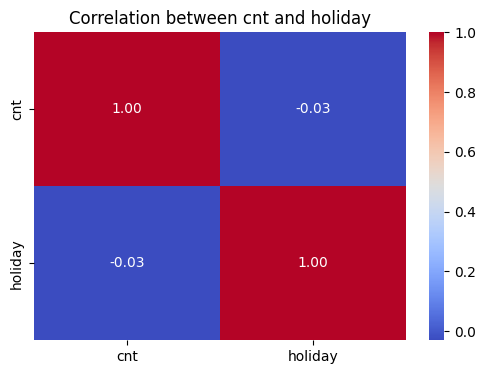

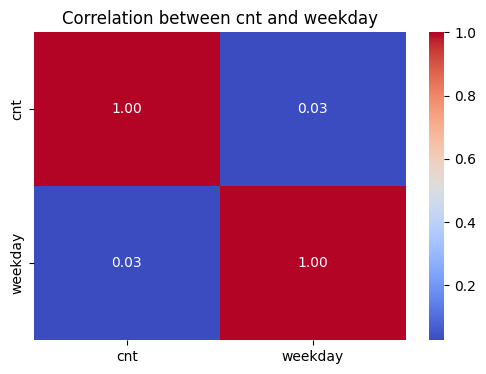

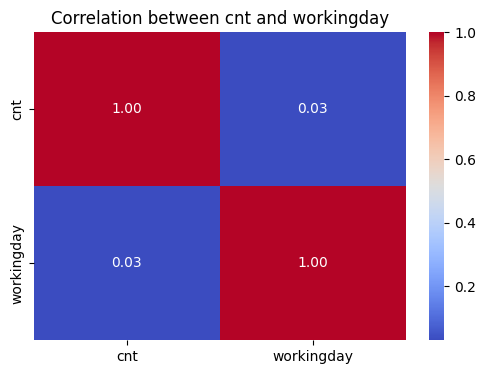

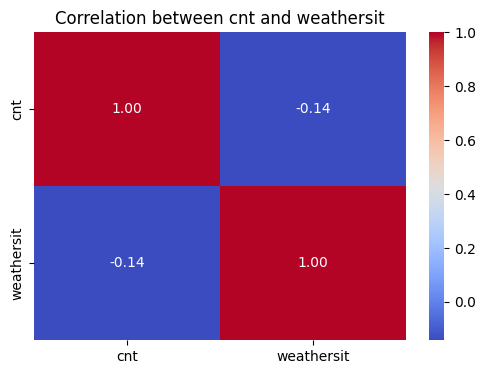

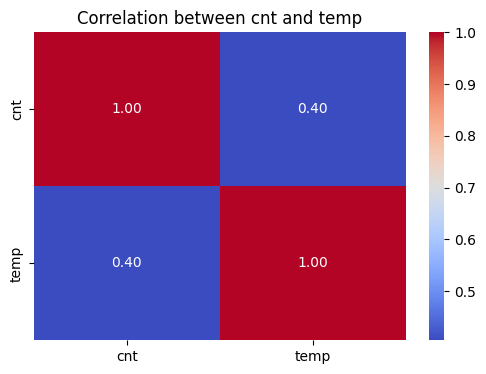

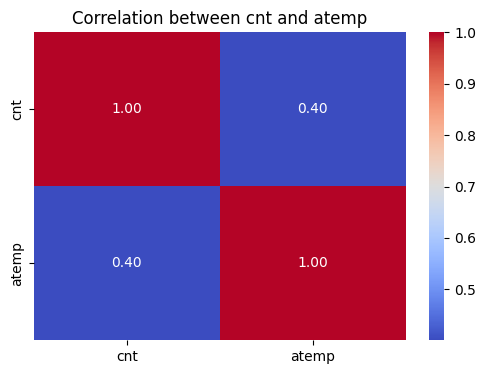

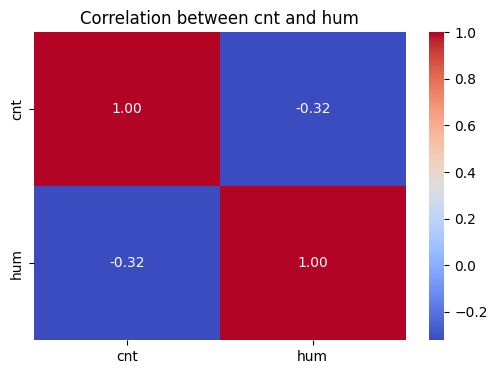

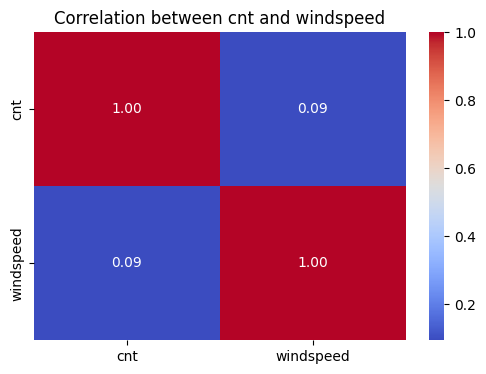

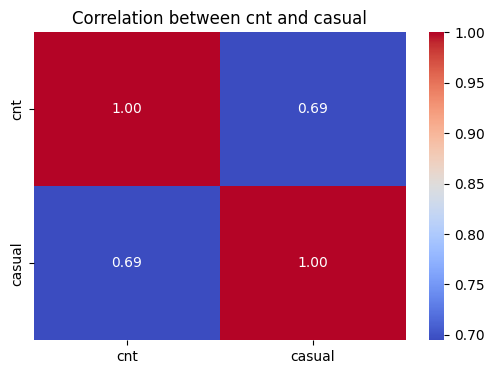

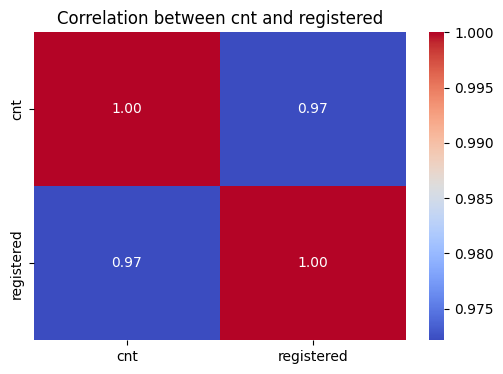

In [97]:
for column in data.columns:
    if column != 'cnt':  # Exclude 'cnt' from predictor variables
        plt.figure(figsize=(6, 4))
        sns.heatmap(data[['cnt', column]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title(f'Correlation between cnt and {column}')
        plt.show()

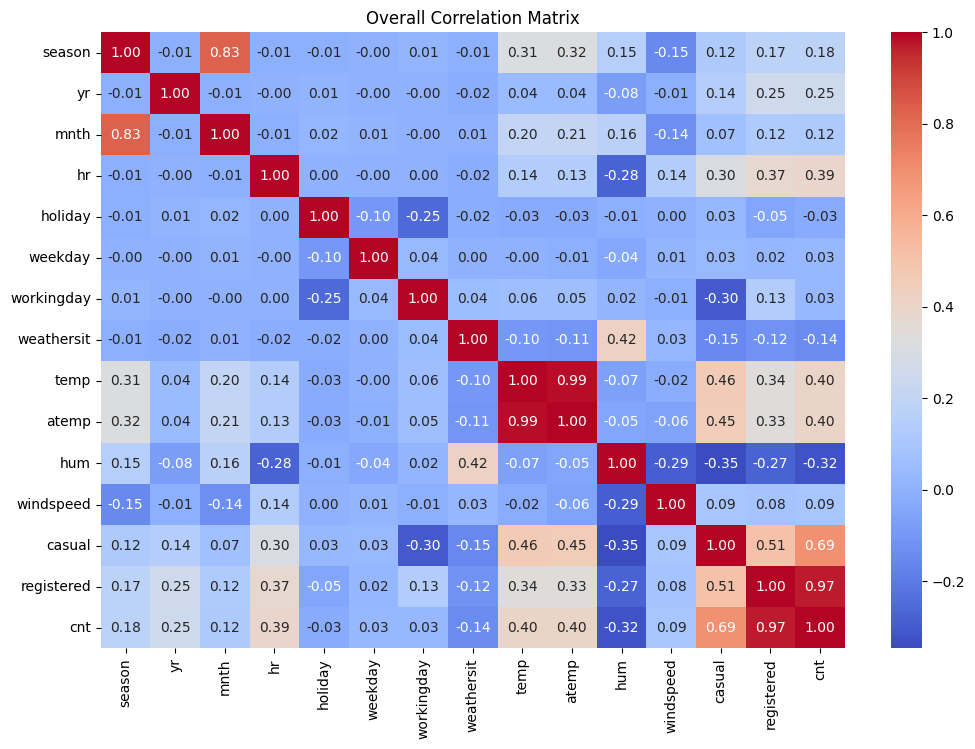

In [98]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Overall Correlation Matrix')
plt.show()

ANOVA for season:
F-statistic: 409.1810372630525, p-value: 7.40107139971279e-257
ANOVA for holiday:
F-statistic: 16.636980484977737, p-value: 4.546168948723332e-05
ANOVA for weathersit:
F-statistic: 127.17386949967266, p-value: 1.7347820521803117e-81


C:\Users\utkso\AppData\Local\Temp\ipykernel_17752\1544776052.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=var, y='cnt', data=data, ci='sd')  # Use standard deviation for error bars
C:\Users\utkso\AppData\Local\Temp\ipykernel_17752\1544776052.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=var, y='cnt', data=data, ci='sd')  # Use standard deviation for error bars
C:\Users\utkso\AppData\Local\Temp\ipykernel_17752\1544776052.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=var, y='cnt', data=data, ci='sd')  # Use standard deviation for error bars


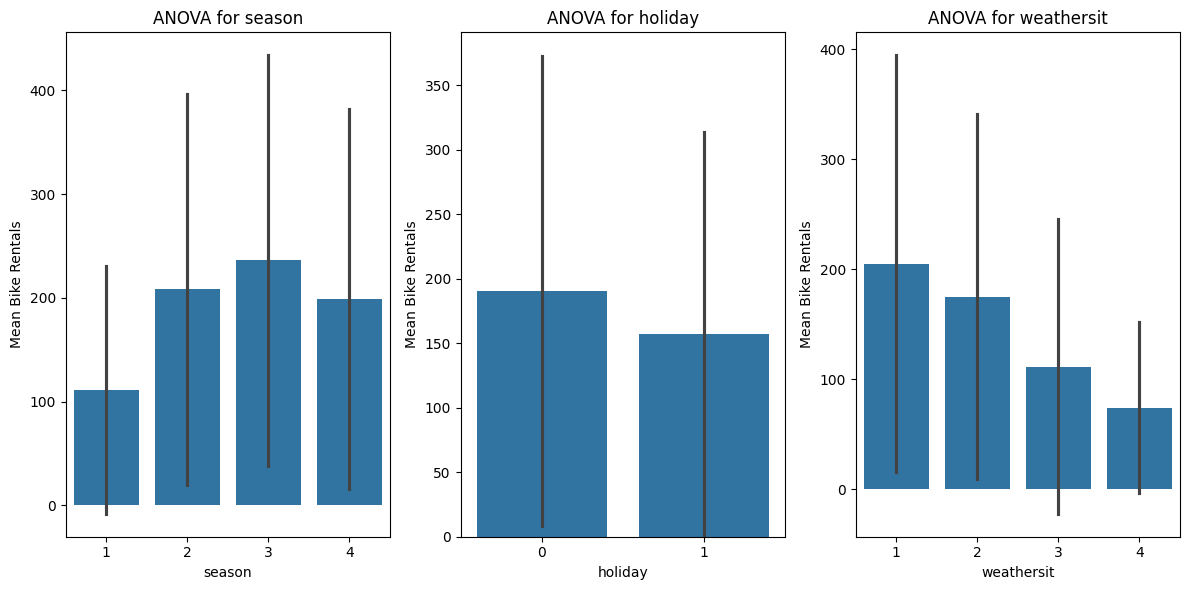

In [99]:
categorical_vars = ['season', 'holiday', 'weathersit']
for var in categorical_vars:
    print(f"ANOVA for {var}:")
    f_statistic, p_value = stats.f_oneway(*[data[data[var] == value]['cnt'] for value in data[var].unique()])
    print(f"F-statistic: {f_statistic}, p-value: {p_value}")
# Create bar plots for ANOVA results
plt.figure(figsize=(12, 6))
for i, var in enumerate(categorical_vars, 1):
    plt.subplot(1, len(categorical_vars), i)
    sns.barplot(x=var, y='cnt', data=data, ci='sd')  # Use standard deviation for error bars
    plt.title(f'ANOVA for {var}')
    plt.xlabel(var)
    plt.ylabel('Mean Bike Rentals')
plt.tight_layout()
plt.show()


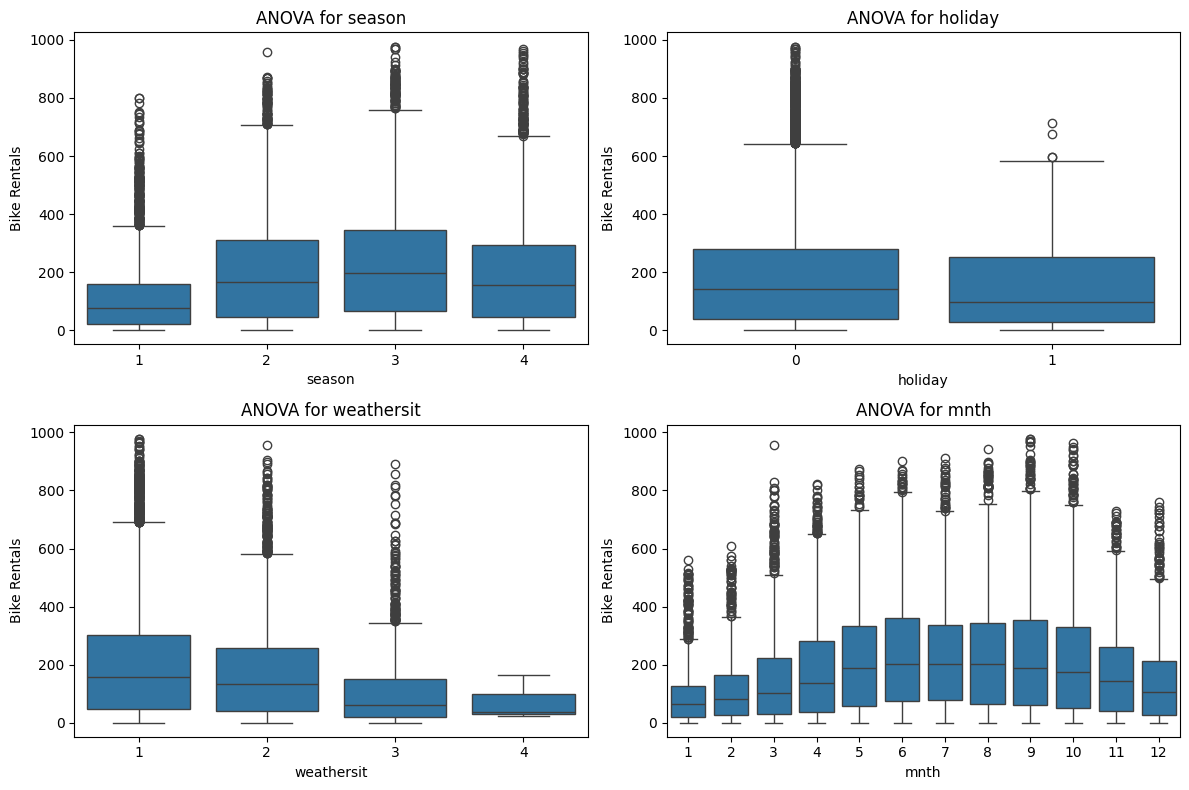

In [100]:
# Additional categorical variables for ANOVA
additional_categorical_vars = ['season', 'holiday', 'weathersit', 'mnth']

# Perform ANOVA for additional categorical variables
plt.figure(figsize=(12, 8))
for i, var in enumerate(additional_categorical_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=var, y='cnt', data=data)
    plt.title(f'ANOVA for {var}')
    plt.xlabel(var)
    plt.ylabel('Bike Rentals')
plt.tight_layout()
plt.show()

T-statistic: -0.22306957521789678, p-value: 0.8234839791816918


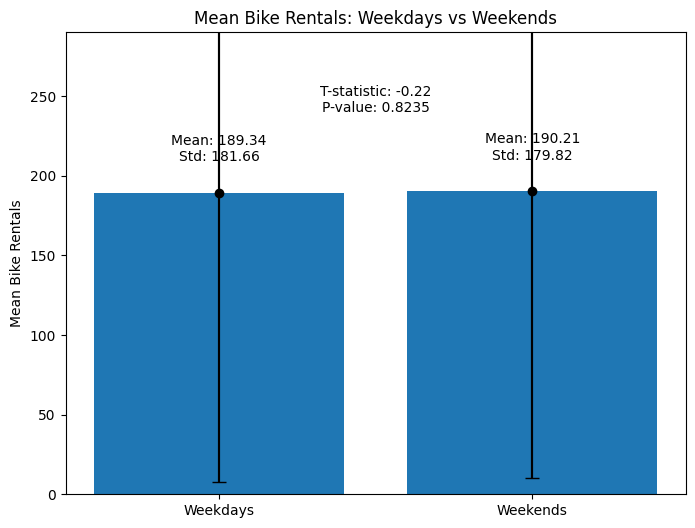

In [101]:
# Hypothesis testing: Compare mean bike rentals between weekdays and weekends
weekday_cnt = data[data['weekday'] <= 5]['cnt']
weekend_cnt = data[data['weekday'] > 5]['cnt']

t_statistic, p_value = stats.ttest_ind(weekday_cnt, weekend_cnt)
print(f"T-statistic: {t_statistic}, p-value: {p_value}")
# Calculate means and standard deviations for weekdays and weekends
weekday_mean = weekday_cnt.mean()
weekend_mean = weekend_cnt.mean()
weekday_std = weekday_cnt.std()
weekend_std = weekend_cnt.std()

# Create bar plot
plt.figure(figsize=(8, 6))
plt.bar(['Weekdays', 'Weekends'], [weekday_mean, weekend_mean], 
        yerr=[weekday_std, weekend_std], capsize=5)
plt.title('Mean Bike Rentals: Weekdays vs Weekends')
plt.ylabel('Mean Bike Rentals')
plt.errorbar(['Weekdays', 'Weekends'], [weekday_mean, weekend_mean], 
             yerr=[weekday_std, weekend_std], fmt='o', color='black')
plt.text(0, weekday_mean + 20, f'Mean: {weekday_mean:.2f}\nStd: {weekday_std:.2f}', ha='center')
plt.text(1, weekend_mean + 20, f'Mean: {weekend_mean:.2f}\nStd: {weekend_std:.2f}', ha='center')
plt.text(0.5, max(weekday_mean, weekend_mean) + 50, f"T-statistic: {t_statistic:.2f}\nP-value: {p_value:.4f}", ha='center')
plt.ylim(0, max(weekday_mean, weekend_mean) + 100)
plt.show()


C:\Users\utkso\AppData\Local\Temp\ipykernel_17752\2278193286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='season', y='cnt', data=data, palette='Set3')


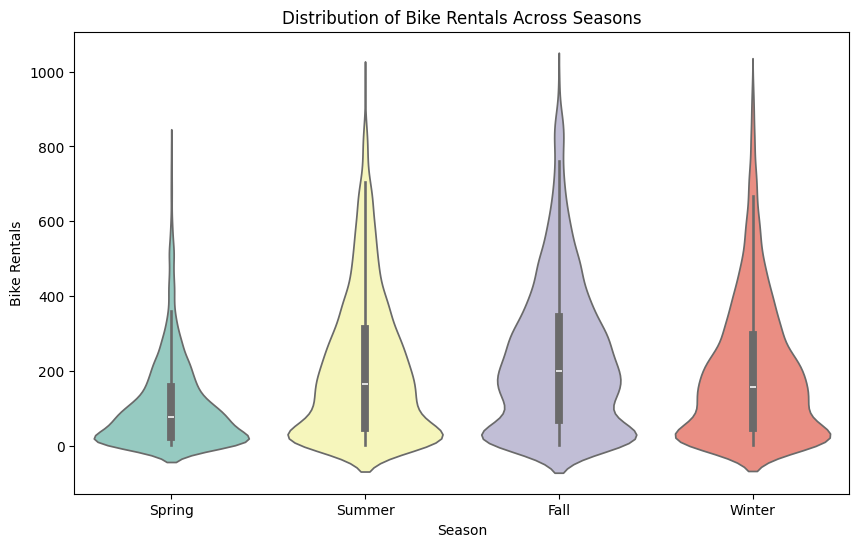

T-test between 1 and 2: T-statistic=-28.56, p-value=0.0000
T-test between 1 and 3: T-statistic=-35.50, p-value=0.0000
T-test between 1 and 4: T-statistic=-26.16, p-value=0.0000
T-test between 2 and 1: T-statistic=28.56, p-value=0.0000
T-test between 2 and 3: T-statistic=-6.76, p-value=0.0000
T-test between 2 and 4: T-statistic=2.37, p-value=0.0178
T-test between 3 and 1: T-statistic=35.50, p-value=0.0000
T-test between 3 and 2: T-statistic=6.76, p-value=0.0000
T-test between 3 and 4: T-statistic=9.09, p-value=0.0000
T-test between 4 and 1: T-statistic=26.16, p-value=0.0000
T-test between 4 and 2: T-statistic=-2.37, p-value=0.0178
T-test between 4 and 3: T-statistic=-9.09, p-value=0.0000


In [102]:
seasons = data['season'].unique()
season_means = [data[data['season'] == season]['cnt'].mean() for season in seasons]

# Create a violin plot to visualize the distribution of bike rentals across seasons
plt.figure(figsize=(10, 6))
sns.violinplot(x='season', y='cnt', data=data, palette='Set3')
plt.title('Distribution of Bike Rentals Across Seasons')
plt.xlabel('Season')
plt.ylabel('Bike Rentals')
plt.xticks(range(len(seasons)), ['Spring', 'Summer', 'Fall', 'Winter'])
plt.show()

# Conduct pairwise hypothesis testing between seasons using t-tests
season_combinations = [(s1, s2) for s1 in seasons for s2 in seasons if s1 != s2]
for s1, s2 in season_combinations:
    season1_cnt = data[data['season'] == s1]['cnt']
    season2_cnt = data[data['season'] == s2]['cnt']
    t_statistic, p_value = stats.ttest_ind(season1_cnt, season2_cnt)
    print(f"T-test between {s1} and {s2}: T-statistic={t_statistic:.2f}, p-value={p_value:.4f}")



C:\Users\utkso\AppData\Local\Temp\ipykernel_17752\1443822278.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bracket_means = data.groupby('windspeed_bracket')['cnt'].mean()
C:\Users\utkso\AppData\Local\Temp\ipykernel_17752\1443822278.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='windspeed_bracket', y='cnt', data=data, palette='Blues', whis=1.5)


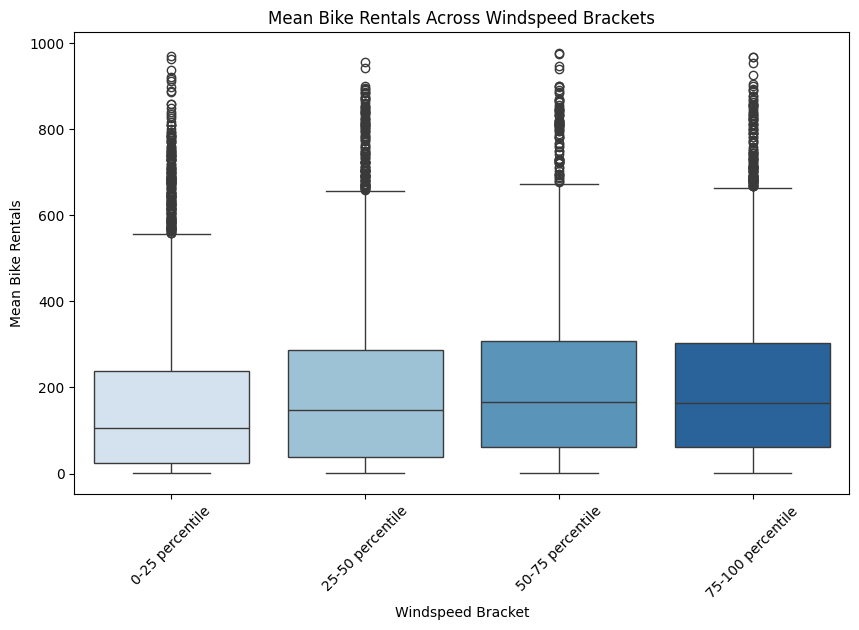

T-test between windspeed brackets 0-25 percentile and 25-50 percentile: T-statistic=-9.13, p-value=0.0000
T-test between windspeed brackets 0-25 percentile and 50-75 percentile: T-statistic=-12.89, p-value=0.0000
T-test between windspeed brackets 0-25 percentile and 75-100 percentile: T-statistic=-13.61, p-value=0.0000
T-test between windspeed brackets 25-50 percentile and 0-25 percentile: T-statistic=9.13, p-value=0.0000
T-test between windspeed brackets 25-50 percentile and 50-75 percentile: T-statistic=-5.05, p-value=0.0000
T-test between windspeed brackets 25-50 percentile and 75-100 percentile: T-statistic=-4.78, p-value=0.0000
T-test between windspeed brackets 50-75 percentile and 0-25 percentile: T-statistic=12.89, p-value=0.0000
T-test between windspeed brackets 50-75 percentile and 25-50 percentile: T-statistic=5.05, p-value=0.0000
T-test between windspeed brackets 50-75 percentile and 75-100 percentile: T-statistic=0.82, p-value=0.4139
T-test between windspeed brackets 75-100

In [103]:
# Define percentiles to create brackets for windspeed
percentiles = [0, 25, 50, 75, 100]

# Create brackets for windspeed using percentiles
windspeed_brackets = np.percentile(data['windspeed'], percentiles)

# Assign labels to windspeed brackets
windspeed_labels = [f"{percentiles[i]}-{percentiles[i+1]} percentile" for i in range(len(percentiles)-1)]

# Map windspeed values to corresponding brackets
data['windspeed_bracket'] = pd.cut(data['windspeed'], bins=windspeed_brackets, labels=windspeed_labels, include_lowest=True)

# Calculate mean bike rentals for each windspeed bracket
bracket_means = data.groupby('windspeed_bracket')['cnt'].mean()

# Create a box plot to visualize mean bike rentals across windspeed brackets
# Create a box plot with adjusted parameters
plt.figure(figsize=(10, 6))
sns.boxplot(x='windspeed_bracket', y='cnt', data=data, palette='Blues', whis=1.5)
plt.title('Mean Bike Rentals Across Windspeed Brackets')
plt.xlabel('Windspeed Bracket')
plt.ylabel('Mean Bike Rentals')
plt.xticks(rotation=45)
plt.show()

# Conduct pairwise hypothesis testing between windspeed brackets using t-tests
bracket_combinations = [(b1, b2) for b1 in windspeed_labels for b2 in windspeed_labels if b1 != b2]
for b1, b2 in bracket_combinations:
    bracket1_cnt = data[data['windspeed_bracket'] == b1]['cnt']
    bracket2_cnt = data[data['windspeed_bracket'] == b2]['cnt']
    t_statistic, p_value = stats.ttest_ind(bracket1_cnt, bracket2_cnt)
    print(f"T-test between windspeed brackets {b1} and {b2}: T-statistic={t_statistic:.2f}, p-value={p_value:.4f}")


MLR

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Define features (X) and target variable (y)
X = data.drop(['cnt'], axis=1)  # Features
y = data['cnt']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the predictor variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the linear regression model
X_train_scaled = sm.add_constant(X_train_scaled)  # Add constant term for intercept
model = sm.OLS(y_train, X_train_scaled).fit()

# Print model summary
print(model.summary())

# Make predictions on the testing set
X_test_scaled = sm.add_constant(X_test_scaled)  # Add constant term for intercept
y_pred = model.predict(X_test_scaled)


ValueError: could not convert string to float: '50-75 percentile'

In [ ]:
# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# Distribution of Residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Scatter Plot of Predicted vs. Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Predicted vs. Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

# QQ Plot
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

# Other Metrics
print(f"Mean Squared Error: {mse}")


In [ ]:
plt.scatter(model.fittedvalues, model.resid)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

LOGIT REG

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Preprocess the test split dataset
X_test_preprocessed = scaler.transform(X_test)

# Make predictions on the preprocessed test dataset
y_pred_test = log_reg_model.predict(X_test_preprocessed)

# Evaluate the model's performance
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_score_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_pred_test)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

# Print the evaluation metrics
print(f"Accuracy on test set: {accuracy_test}")
print(f"Precision on test set: {precision_test}")
print(f"Recall on test set: {recall_test}")
print(f"F1 Score on test set: {f1_score_test}")
print(f"ROC AUC on test set: {roc_auc_test}")
print("Confusion Matrix on test set:")
print(conf_matrix_test)

import seaborn as sns

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, cmap='Blues', fmt='d', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Plot Classification Report
from sklearn.metrics import precision_recall_fscore_support

precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_test, average=None)
metrics_df = pd.DataFrame({'Precision': precision, 'Recall': recall, 'F1-score': fscore}, index=['Negative', 'Positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(metrics_df, annot=True, cmap='Blues', fmt=".3f")
plt.xlabel('Metrics')
plt.ylabel('Labels')
plt.title('Classification Report (Test Set)')
plt.show()

# Multicollinearity Test
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factors:")
print(vif_data)

# Calculate correlation matrix
corr_matrix = X.corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [107]:
logarithmic_regression_values = (5877.791, 5083.909, 0.398075, '> 0.1')
linear_regression_values = (631.241, 11241.85, 0.332847, '129.1%')

print("Logarithmic regression: f(x) = {:.3f} * ln(x) + {:.3f}".format(*logarithmic_regression_values[:2]))
print("R² =", logarithmic_regression_values[2])
print("p =", logarithmic_regression_values[3])

print("Linear regression: f(x) = {:.3f} * (x - 1) + {:.3f}".format(*linear_regression_values[:2]))
print("R² =", linear_regression_values[2])

print("Percentage increase:", linear_regression_values[3])


Logarithmic regression: f(x) = 5877.791 * ln(x) + 5083.909
R² = 0.398075
p = > 0.1
Linear regression: f(x) = 631.241 * (x - 1) + 11241.850
R² = 0.332847
Percentage increase: 129.1%


In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert dates to datetime objects
data['dteday'] = pd.to_datetime(data['dteday'])

# Create a DataFrame
df = pd.DataFrame(data)

# Extract year and month from the 'dteday' column
df['year'] = df['dteday'].dt.year
df['month'] = df['dteday'].dt.month

# Group by year and month, calculate mean humidity
monthly_humidity = df.groupby(['year', 'month'])['hum'].mean().unstack()

# Plot
monthly_humidity.plot(marker='o', figsize=(10, 6))
plt.title('Monthly Humidity by Year')
plt.xlabel('Month')
plt.ylabel('Humidity')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.grid(True)
plt.show()


KeyError: 'dteday'